In [1]:
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
import warnings 
warnings.filterwarnings('ignore');

In [2]:
df=pd.read_csv(r'D:\ML\machne\insurance.csv')

<Axes: >

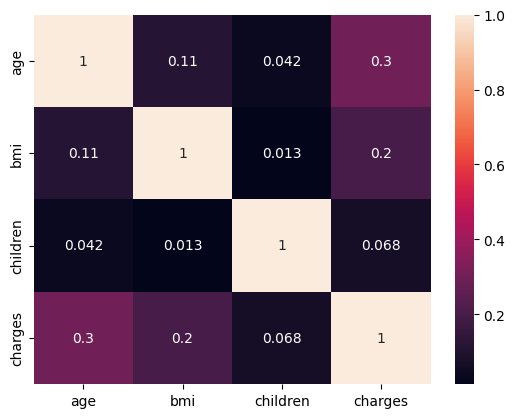

In [3]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [4]:
df_ceaned=df.copy()

df_ceaned.drop_duplicates(inplace=True)

In [5]:
df_ceaned.shape

(1337, 7)

In [6]:
df_ceaned.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [7]:
numcom=df_ceaned.select_dtypes(include='number').columns
print(numcom)

Index(['age', 'bmi', 'children', 'charges'], dtype='object')


In [8]:
nonumcom=df_ceaned.select_dtypes(exclude='number').columns
print(nonumcom)

Index(['sex', 'smoker', 'region'], dtype='object')


In [9]:
df_ceaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [10]:
for co in nonumcom:
    print(df_ceaned[co].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


In [11]:
df_ceaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [12]:
df_ceaned.shape

(1337, 7)

In [13]:
df_ceaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [14]:
df_ceaned['sex']=df_ceaned['sex'].map({"male":0,"female":1})

In [15]:
df_ceaned['smoker']=df_ceaned['smoker'].map({"no":0,"yes":1})

In [16]:
df_ceaned.rename(columns={
    'sex':'isfemle',
    'smoker':'issmoker'
},inplace=True)

In [17]:
df_ceaned.shape

(1337, 7)

In [18]:
df_ceaned.head()

,age,isfemle,bmi,children,issmoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [19]:
df_ceaned.shape 

(1337, 7)

In [20]:
df_ceaned=pd.get_dummies(df_ceaned,columns=['region'])
df_ceaned=df_ceaned.astype(int)

In [21]:
df_ceaned['bmi_category']=pd.cut(
    df_ceaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['underweight','normal','over','obese']
)

In [22]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler=StandardScaler()
df_ceaned[cols]=scaler.fit_transform(df_ceaned[cols])

In [23]:
df_ceaned=pd.get_dummies(df_ceaned,columns=['bmi_category'])
df_ceaned=df_ceaned.astype(int)
df_ceaned.head()

,age,isfemle,bmi,children,issmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_over,bmi_category_obese
0,-1,1,0,0,1,16884,0,0,0,1,0,0,1,0
1,-1,0,0,0,0,1725,0,0,1,0,0,0,0,1
2,0,0,0,1,0,4449,0,0,1,0,0,0,0,1
3,0,0,-1,0,0,21984,0,1,0,0,0,1,0,0
4,0,0,0,0,0,3866,0,1,0,0,0,0,1,0


In [24]:
# Correlation with target column
correlations = df_ceaned.corr()['charges'].sort_values(ascending=False)
print(correlations)

charges                     1.000000
issmoker                    0.787234
age                         0.253749
bmi_category_obese          0.200348
bmi                         0.127252
region_southeast            0.073577
children                    0.013179
region_northeast            0.005946
region_northwest           -0.038695
region_southwest           -0.043637
bmi_category_underweight   -0.050599
isfemle                    -0.058046
bmi_category_normal        -0.104042
bmi_category_over          -0.120601
Name: charges, dtype: float64


In [25]:
df_ceaned.columns

Index(['age', 'isfemle', 'bmi', 'children', 'issmoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_underweight', 'bmi_category_normal',
       'bmi_category_over', 'bmi_category_obese'],
      dtype='object')

In [26]:
cat_cols=['isfemle','issmoker','region_northeast', 'region_northwest', 'region_southeast',
        'region_southwest', 'bmi_category_underweight', 'bmi_category_normal',
                 'bmi_category_over', 'bmi_category_obese']
df_ceaned['charges_bins']=pd.qcut(df_ceaned['charges'],q=4,labels=False)
from scipy.stats import chi2_contingency

# Chi-Square test for each categorical column
for col in cat_cols:
    contingency_table = pd.crosstab(df_ceaned[col], df_ceaned['charges_bins'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    print(f"Column: {col}")
    print(f"Chi2: {chi2:.2f}, p-value: {p:.4f}")
    if p < 0.05:
        print("=> Dependent on target (significant)\n")
    else:
        print("=> Independent of target (not significant)\n")
    

Column: isfemle
Chi2: 10.26, p-value: 0.0165
=> Dependent on target (significant)

Column: issmoker
Chi2: 848.22, p-value: 0.0000
=> Dependent on target (significant)

Column: region_northeast
Chi2: 6.44, p-value: 0.0921
=> Independent of target (not significant)

Column: region_northwest
Chi2: 1.13, p-value: 0.7688
=> Independent of target (not significant)

Column: region_southeast
Chi2: 16.00, p-value: 0.0011
=> Dependent on target (significant)

Column: region_southwest
Chi2: 5.09, p-value: 0.1652
=> Independent of target (not significant)

Column: bmi_category_underweight
Chi2: 3.37, p-value: 0.3375
=> Independent of target (not significant)

Column: bmi_category_normal
Chi2: 3.71, p-value: 0.2948
=> Independent of target (not significant)

Column: bmi_category_over
Chi2: 4.25, p-value: 0.2356
=> Independent of target (not significant)

Column: bmi_category_obese
Chi2: 8.52, p-value: 0.0365
=> Dependent on target (significant)



In [27]:
df_ceaned=df_ceaned[['age', 'isfemle', 'bmi', 'children', 'issmoker', 'charges', 'region_southeast', 'bmi_category_obese'
]]


In [28]:
df_ceaned.head()

,age,isfemle,bmi,children,issmoker,charges,region_southeast,bmi_category_obese
0,-1,1,0,0,1,16884,0,0
1,-1,0,0,0,0,1725,1,1
2,0,0,0,1,0,4449,1,1
3,0,0,-1,0,0,21984,0,0
4,0,0,0,0,0,3866,0,0


In [29]:
df_ceaned.shape

(1337, 8)

In [30]:
from sklearn.model_selection import train_test_split
x=df_ceaned.drop('charges',axis=1)
y=df_ceaned['charges']

In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
from sklearn.linear_model import LinearRegression

In [32]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_pred=model.predict(x_test)


In [34]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
r2

0.7951235263718375

In [35]:
n=x_test.shape[0]
p=x_test.shape[1]
adjr2=1-((1-r2)*(n-1)/(n-p-1))
adjr2

0.7896076213126177